# Class Balancing

Compare SMOTE vs ADASYN vs no balancing via cross-validation (resampling
done per-fold to avoid leakage), then apply the chosen method to the full
training set.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from churn.config import PROCESSED_DIR
from churn.balancing.balance import compare_balancers, apply_balancing

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

train = pd.read_parquet(PROCESSED_DIR / "train_selected.parquet")
comparison = compare_balancers(train)
print(comparison)

none: recall=0.045, precision=0.510, f1=0.083, roc_auc=0.893


smote: recall=0.874, precision=0.272, f1=0.415, roc_auc=0.876


adasyn: recall=0.871, precision=0.265, f1=0.406, roc_auc=0.871
          recall  precision        f1   roc_auc
none    0.045371   0.509991  0.083289  0.892840
smote   0.874034   0.272390  0.415329  0.876345
adasyn  0.871416   0.264936  0.406318  0.870631


## Metric comparison — none vs SMOTE vs ADASYN

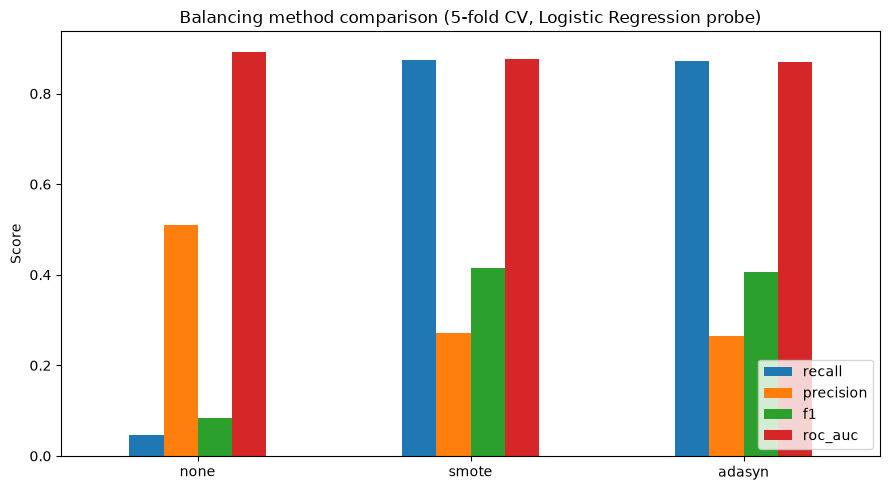

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison[["recall", "precision", "f1", "roc_auc"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Balancing method comparison (5-fold CV, Logistic Regression probe)")
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
save_fig(fig, "08_balancing_comparison")
plt.show()

## Class distribution before vs after SMOTE

Balanced train (smote): 501600 rows, churn rate = 50.00% (original: 275243 rows, 8.88%)


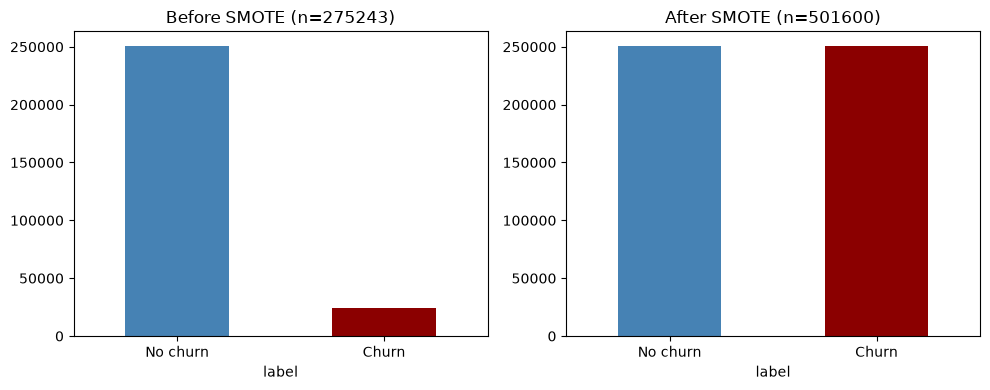

In [3]:
train_balanced = apply_balancing(train, method="smote")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train["label"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "darkred"])
axes[0].set_title(f"Before SMOTE (n={len(train)})")
axes[0].set_xticklabels(["No churn", "Churn"], rotation=0)

train_balanced["label"].value_counts().plot(kind="bar", ax=axes[1], color=["steelblue", "darkred"])
axes[1].set_title(f"After SMOTE (n={len(train_balanced)})")
axes[1].set_xticklabels(["No churn", "Churn"], rotation=0)

plt.tight_layout()
save_fig(fig, "09_class_distribution_before_after_smote")
plt.show()

train_balanced.to_parquet(PROCESSED_DIR / "train_balanced.parquet", index=False)

**Observations — Class balancing**

- **Without balancing, the model misses almost all churners** (recall = 0.045), despite a high ROC-AUC (0.893). This shows that ROC-AUC alone can be misleading on imbalanced data.
- **SMOTE greatly improves recall** (0.874), identifying most churners at the cost of more false positives. Since the goal is to identify customers at risk of leaving, higher recall is preferred.
- **SMOTE performs slightly better than ADASYN** across all evaluation metrics, so it is selected as the balancing method.
- **The Logistic Regression convergence warnings are expected**, as feature scaling has not yet been applied. They do not affect the comparison between balancing methods.
- **The final balanced training set** contains **501,600 subscribers** with a **50/50 class distribution**.

**Decision:** Use **SMOTE** to balance the training set. The test set remains unchanged with its original **8.88% churn rate**.